<a href="https://colab.research.google.com/github/bratzlernathan-cloud/lis4693/blob/main/copy_of_final_project_draft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from itertools import combinations

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2019/2019-06-25/ufo_sightings.csv")
print(f"Total UFO reports: {len(df)}")


Total UFO reports: 80332


In [ ]:

stop_words = set(stopwords.words('english'))
stop_words.update(['one', 'two', 'three', 'nuforc', 'quot', 'approximately', 'saw', 'looked', 'appeared', 'moved', 'seen', 'like', 'around', 'across', 'large', 'high', 'low', 'north', 'south', 'east', 'west', 'minute', 'second', 'ufo', 'sighting', 'object', 'craft', 'shape', 'note',
'near', 'area', 'direction', 'time', 'away', 'driving', 'observed', 'small', 'slow', 'wa', 'see'])
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text):
        return ''
    text = text.replace('&#44', ' ').replace('&amp;', ' ')
    text = re.sub(r'[^a-zA-Z\s]', ' ', text.lower()).strip()
    return text

def preprocess(text):
    text = clean_text(text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word)
              for word in tokens
              if lemmatizer.lemmatize(word) not in stop_words and len(word) > 2]
    return ' '.join(tokens)

# Apply preprocessing
df['clean_description'] = df['description'].apply(clean_text)
df['processed'] = df['clean_description'].apply(preprocess)

print("Preprocessing completed successfully!")
print(df[['description', 'processed']].head())

Preprocessing completed successfully!
                                         description  \
0  This event took place in early fall around 194...   
1  1949 Lackland AFB&#44 TX.  Lights racing acros...   
2  Green/Orange circular disc over Chester&#44 En...   
3  My older brother and twin sister were leaving ...   
4  AS a Marine 1st Lt. flying an FJ4B fighter/att...   

                                           processed  
0  event took place early fall occurred boy scout...  
1  lackland afb light racing sky making degree tu...  
2         green orange circular disc chester england  
3  older brother twin sister leaving edna theater...  
4  marine flying fighter attack aircraft solo nig...  


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
vectorizer = CountVectorizer(max_df=0.95, min_df=10, stop_words='english')
dtm = vectorizer.fit_transform(df['processed'])

In [ ]:
n_topics = 8
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(dtm)

LatentDirichletAllocation(n_components=8, random_state=42)

In [ ]:
feature_names = vectorizer.get_feature_names_out()

print("\n=== Topics Found ===")
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-12:-1]]
    print(f"Topic {topic_idx}: {', '.join(top_words)}")


=== Topics Found ===
Topic 0: speed, possible, aircraft, new, jet, rate, sky, year, plane, flying, morning
Topic 1: light, orange, flying, bright, green, orb, ball, white, red, blue, round
Topic 2: fireball, orange, sphere, hovering, glowing, city, road, sighted, flying, mile, space
Topic 3: light, strange, bright, orange, red, white, witness, sky, beach, hovering, noise
Topic 4: star, light, sky, looking, noticed, night, outside, went, friend, home, thought
Topic 5: sky, light, bright, night, orange, disappeared, star, changed, moving, colored, slowly
Topic 6: shaped, triangle, light, triangular, black, disk, silver, cigar, white, silent, saucer
Topic 7: light, moving, red, sky, fast, bright, white, flashing, star, formation, blinking


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
all_words = ' '.join(df['processed']).split()
word_freq = Counter(all_words)
top_words = [word for word, freq in word_freq.most_common(50)]

In [ ]:
G = nx.Graph()

for text in df['processed']:
    words_in_doc = [w for w in text.split() if w in top_words]
    for word1, word2 in combinations(set(words_in_doc), 2): #Avoiding duplicates
        if G.has_edge(word1, word2):
            G[word1][word2]['weight'] += 1
        else:
            G.add_edge(word1, word2, weight=1)

Network image saved as network.png


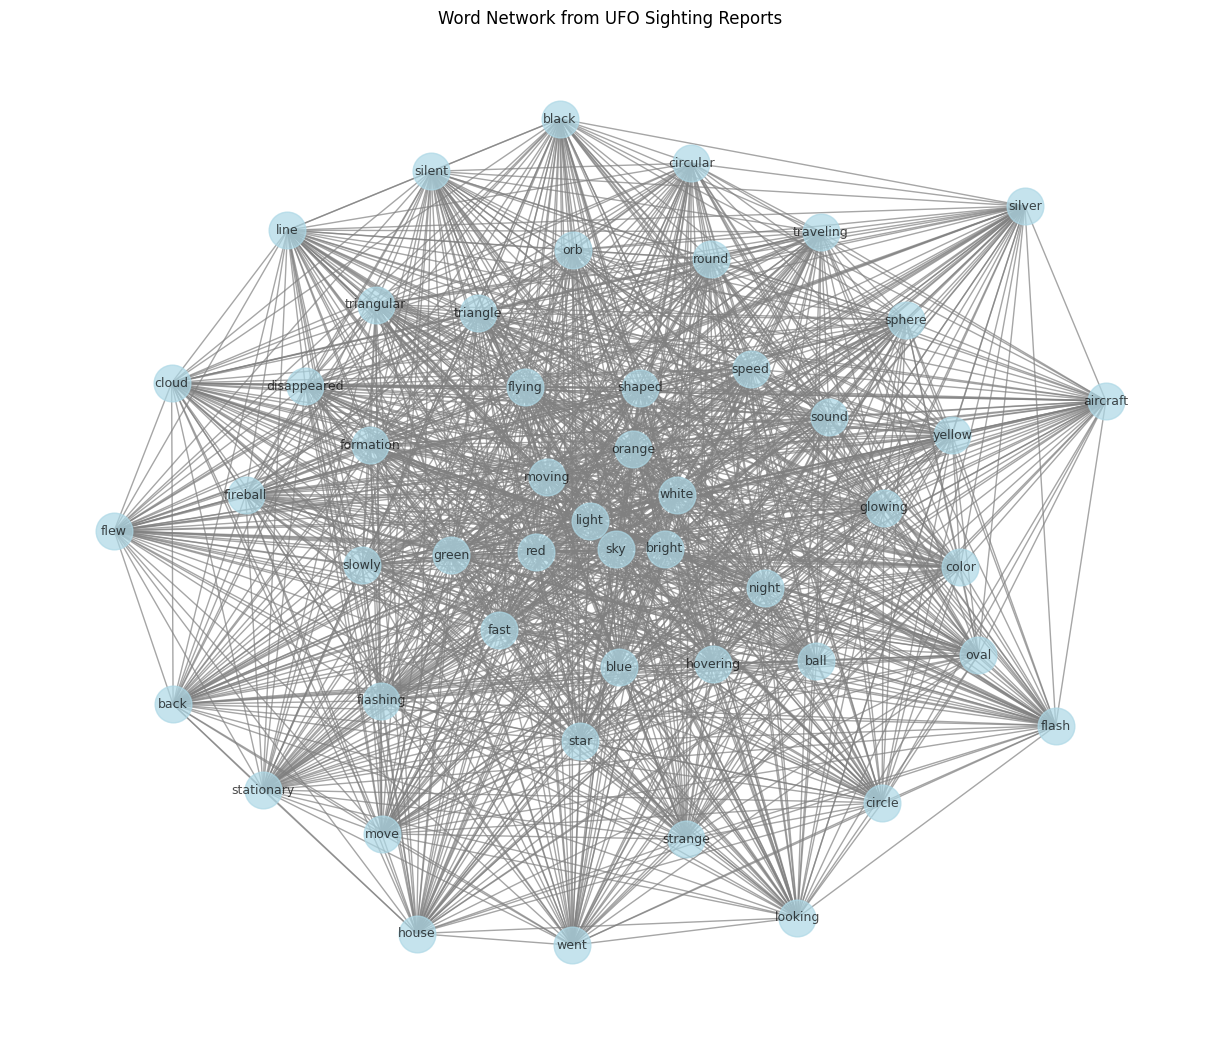

In [ ]:
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.6)
nx.draw(G, pos, with_labels=True, node_size=700, node_color='lightblue',
        font_size=9, edge_color='gray', alpha=0.7)
plt.title("Word Network from UFO Sighting Reports")
plt.savefig("network.png", dpi=300, bbox_inches='tight')
print("Network image saved as network.png")

In [ ]:
import altair as alt

top15 = pd.DataFrame(word_freq.most_common(15), columns=['word', 'count'])

chart = alt.Chart(top15).mark_bar(color='steelblue').encode(
    x=alt.X('count:Q', title='Frequency'),
    y=alt.Y('word:N', sort='-x', title='Word')
).properties(
    title='Most Common Words in UFO Reports',
    width=600,
    height=400
)

chart.display()

alt.Chart(...)

In [ ]:
print(df.columns.tolist())

['date_time', 'city_area', 'state', 'country', 'ufo_shape', 'encounter_length', 'described_encounter_length', 'description', 'date_documented', 'latitude', 'longitude', 'clean_description', 'processed']


In [ ]:
df_ml = df.dropna(subset=['ufo_shape', 'processed'])
df_ml = df_ml[~df_ml['ufo_shape'].isin(['unknown', 'other'])]

shape_counts = df_ml['ufo_shape'].value_counts()
valid_shapes = shape_counts[shape_counts >= 50].index
df_ml = df_ml[df_ml['ufo_shape'].isin(valid_shapes)]

print(df_ml['ufo_shape'].value_counts())
print(f'Total records for ML: {len(df_ml)}')

ufo_shape
light        16565
triangle      7865
circle        7608
fireball      6208
sphere        5387
disk          5213
oval          3733
formation     2457
cigar         2057
changing      1962
flash         1328
rectangle     1297
cylinder      1283
diamond       1178
chevron        952
egg            759
teardrop       750
cone           316
cross          233
Name: count, dtype: int64
Total records for ML: 67151


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


x = df_ml['processed']
y = df_ml['ufo_shape']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = .3, random_state = 42, stratify =y)

x_train = x_train.fillna('')
x_test = x_test.fillna('')

preprocessing = Pipeline([
    ('vect', CountVectorizer(ngram_range=(1,2), max_features=50000)),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(x_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(x_test)

print("Training Logistic Regression classifier...")
lr_classifier = LogisticRegression(max_iter=1000)
lr_classifier.fit(train_preprocessed, y_train)

y_pred = lr_classifier.predict(test_preprocessed)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Preprocessing training data...
Preprocessing test data...
Training Logistic Regression classifier...

Accuracy: 0.5521

Classification Report:
              precision    recall  f1-score   support

    changing       0.54      0.10      0.17       589
     chevron       0.79      0.39      0.52       286
       cigar       0.88      0.48      0.62       617
      circle       0.42      0.35      0.38      2282
        cone       0.86      0.32      0.46        95
       cross       0.81      0.19      0.30        70
    cylinder       0.84      0.36      0.50       385
     diamond       0.86      0.43      0.57       353
        disk       0.53      0.54      0.53      1564
         egg       0.92      0.38      0.54       228
    fireball       0.72      0.61      0.66      1862
       flash       0.62      0.33      0.43       398
   formation       0.47      0.22      0.30       737
       light       0.46      0.84      0.59      4970
        oval       0.75      0.37      0.50   

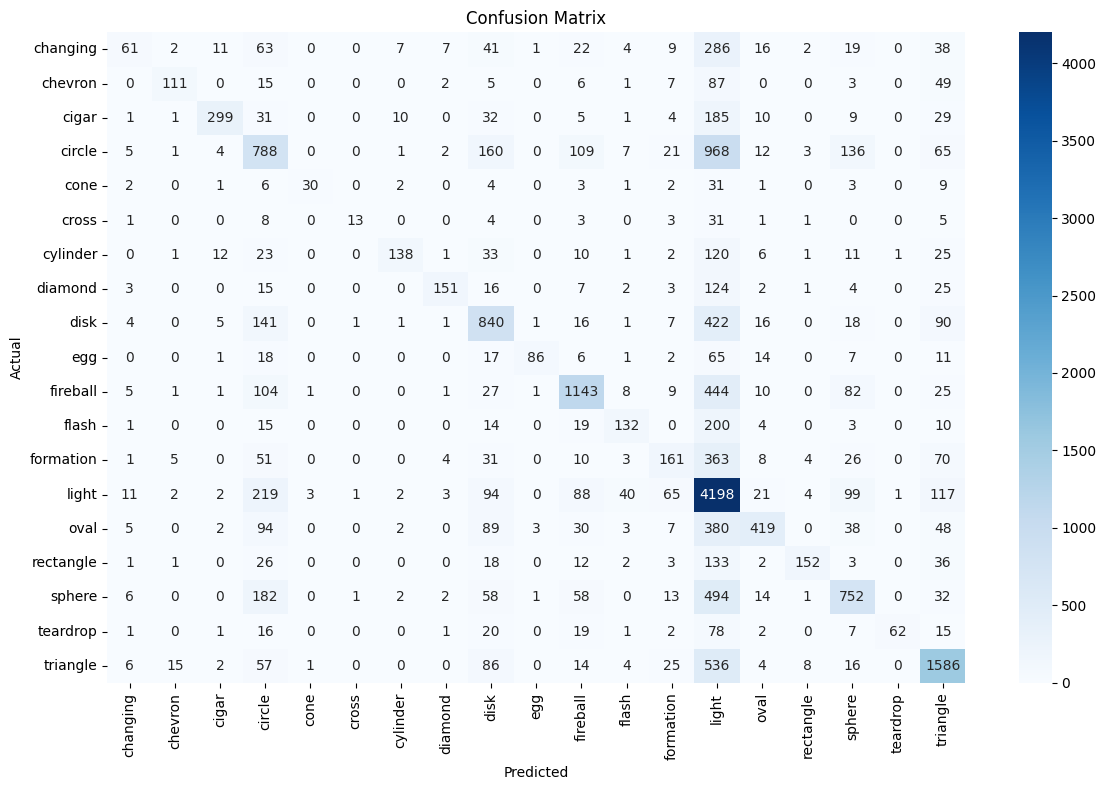

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels = lr_classifier.classes_)
plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt= 'd', xticklabels = lr_classifier.classes_,
            yticklabels=lr_classifier.classes_, cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

=== ORIGINAL DATASET ===
ufo_shape
light        16565
triangle      7865
circle        7608
fireball      6208
other         5649
unknown       5584
sphere        5387
disk          5213
oval          3733
formation     2457
cigar         2057
changing      1962
NaN           1932
flash         1328
rectangle     1297
cylinder      1283
diamond       1178
chevron        952
egg            759
teardrop       750
cone           316
cross          233
delta            7
round            2
crescent         2
pyramid          1
flare            1
hexagon          1
dome             1
changed          1
Name: count, dtype: int64

Total unique shapes: 29
